# Bird Song Generation
## Stage 3: Classifier Architecture Study

This notebook uses the CRNN as the worked classifier example while preserving
the recorded four-architecture comparison as selection evidence. All model
definitions and checkpoint loading come from src; this notebook is a gated
companion, not a second implementation.


## Goal

1. Inspect the shared cached log-mel representation.
2. Use the CRNN to demonstrate the classifier data and inference path.
3. Visualize the recorded four-architecture, three-seed validation comparison.
4. Keep fresh training opt-in and use content-safe manifests for new runs.
5. Show the packaged held-out CRNN result without repeatedly tuning on test.


## Setup

The notebook imports model definitions and checkpoint logic from `src/` instead of maintaining a second implementation. This keeps notebook experiments consistent with the command-line pipeline.

In [1]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

# Work when opened from either the repository root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from bird_song.classifier.model import ARCHITECTURES, build_classifier, count_trainable_parameters
from bird_song.config import SpectrogramConfig
from bird_song.data import ManifestDataset, make_loader, resolve_spectrogram_cache_root
from bird_song.runtime import load_checkpoint, seed_everything

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.set_float32_matmul_precision("high")
    torch.backends.cudnn.benchmark = True
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Project root: C:\Users\Harvey\Documents\Coding\bird_song_gen
PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER


### Experiment Configuration

The default comparison repeats each architecture with three seeds. `NOTEBOOK_WORKERS = 0` is safe for interactive data previews; the standalone training subprocess can use more workers on Windows.

In [2]:
CONTENT_SAFE_ROOT = PROJECT_ROOT / "manifests" / "content_safe_v2"
TRAIN_MANIFEST = CONTENT_SAFE_ROOT / "full_dataset_train.csv"
VALIDATION_MANIFEST = CONTENT_SAFE_ROOT / "full_dataset_validation.csv"
TEST_MANIFEST = CONTENT_SAFE_ROOT / "full_dataset_test.csv"
CACHE_ROOT = PROJECT_ROOT / "artifacts" / "spectrograms"
CONFIG_PATH = PROJECT_ROOT / "configs" / "spectrogram.json"
REFERENCE_CHECKPOINT = PROJECT_ROOT / "artifacts" / "models" / "classifier" / "selected_crnn" / "best.pt"
SELECTED_METRICS_PATH = PROJECT_ROOT / "artifacts" / "models" / "classifier" / "selected_crnn" / "metrics.json"
SELECTED_CONFUSION_PATH = PROJECT_ROOT / "artifacts" / "models" / "classifier" / "selected_crnn" / "confusion_matrix.csv"
LOCAL_SINGLE_RUN_ROOT = PROJECT_ROOT / "runs" / "notebook_classifier"
LOCAL_COMPARISON_ROOT = PROJECT_ROOT / "runs" / "classifier_architectures"
RECORDED_COMPARISON_ROOT = PROJECT_ROOT / "artifacts" / "models" / "classifier" / "architecture_comparison"
USE_LOCAL_COMPARISON_RESULTS = False
ACTIVE_COMPARISON_ROOT = LOCAL_COMPARISON_ROOT if USE_LOCAL_COMPARISON_RESULTS else RECORDED_COMPARISON_ROOT

SELECTED_ARCHITECTURE = "crnn"
ARCHITECTURES_TO_COMPARE = list(ARCHITECTURES)
COMPARISON_SEEDS = [42, 123, 777]
SEED = 42
BATCH_SIZE = 64
NOTEBOOK_WORKERS = 0
TRAINING_WORKERS = 4
EPOCHS = 40
PATIENCE = 8
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.05
WIDTH = 32
DROPOUT = 0.30

RUN_SINGLE_MODEL = False
RUN_ARCHITECTURE_COMPARISON = False
OVERWRITE_RUNS = False
RUN_TEST_EVALUATION = False
FINAL_CHECKPOINT = REFERENCE_CHECKPOINT

for required_path in (TRAIN_MANIFEST, VALIDATION_MANIFEST, TEST_MANIFEST, CACHE_ROOT / "spectrogram_manifest.csv"):
    if not required_path.is_file():
        raise FileNotFoundError(f"Required classifier input is missing: {required_path}")
assert SELECTED_ARCHITECTURE in ARCHITECTURES
assert set(ARCHITECTURES_TO_COMPARE).issubset(ARCHITECTURES)
seed_everything(SEED)


## Data

Fresh classifier reruns use the content-safe v2 manifests and the canonical
fixed spectrogram cache. The recorded architecture comparison below predates
this cache/content-safe rerun boundary, so it remains labeled as historical
selection evidence rather than being silently recomputed.


In [3]:
spectrogram_cache_root = resolve_spectrogram_cache_root(PROJECT_ROOT, CACHE_ROOT)
spectrogram_config = SpectrogramConfig.from_json(CONFIG_PATH)
classes = tuple(sorted(pd.read_csv(TRAIN_MANIFEST)["name"].unique()))

train_set = ManifestDataset(
    TRAIN_MANIFEST,
    None,
    classes,
    spectrogram_config,
    training=True,
    spectrogram_cache_root=spectrogram_cache_root,
)
validation_set = ManifestDataset(
    VALIDATION_MANIFEST,
    None,
    classes,
    spectrogram_config,
    training=False,
    spectrogram_cache_root=spectrogram_cache_root,
)
test_set = ManifestDataset(
    TEST_MANIFEST,
    None,
    classes,
    spectrogram_config,
    training=False,
    spectrogram_cache_root=spectrogram_cache_root,
)

train_loader = make_loader(train_set, BATCH_SIZE, NOTEBOOK_WORKERS, training=True, seed=SEED)
validation_loader = make_loader(validation_set, BATCH_SIZE, NOTEBOOK_WORKERS)
test_loader = make_loader(test_set, BATCH_SIZE, NOTEBOOK_WORKERS)
preview_specs, preview_labels, preview_paths = next(iter(train_loader))

split_summary = pd.concat(
    [
        pd.read_csv(TRAIN_MANIFEST).assign(split="train"),
        pd.read_csv(VALIDATION_MANIFEST).assign(split="validation"),
        pd.read_csv(TEST_MANIFEST).assign(split="test"),
    ]
)[["split", "name"]].value_counts().rename("clips").reset_index()
display(split_summary)
print("Classes:", classes)
print("Input shape:", (1, spectrogram_config.n_mels, spectrogram_config.spectrogram_width))
print("Cache root:", spectrogram_cache_root)


,split,name,clips
0,train,Song Sparrow,866
1,train,Northern Cardinal,740
2,train,American Robin,709
3,validation,Song Sparrow,184
4,test,Song Sparrow,182
5,validation,Northern Cardinal,172
6,validation,American Robin,163
7,test,Northern Cardinal,162
8,test,American Robin,145


Classes: ('American Robin', 'Northern Cardinal', 'Song Sparrow')
Input shape: (1, 128, 128)
Cache root: C:\Users\Harvey\Documents\Coding\bird_song_gen\artifacts\spectrograms


### Visualize a Training Batch

The examples can include random crop, gain, noise, frequency masking, or time masking because they come from the training loader.

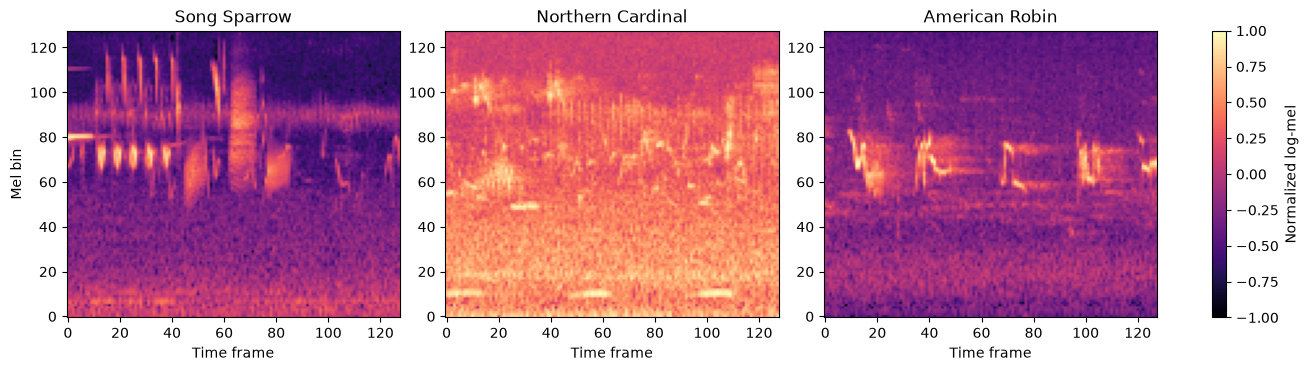

Batch shape: (64, 1, 128, 128)
First cached file: C:\Users\Harvey\Documents\Coding\bird_song_gen\artifacts\spectrograms\objects\9e\9e90c2526c7cf5e050dc578d2e99a4c08c543f1e80db8742e0e43cf0b26747e5.npy


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
for axis, spec, label in zip(axes, preview_specs[:3], preview_labels[:3]):
    image = axis.imshow(
        spec.squeeze(0), origin="lower", aspect="auto", cmap="magma", vmin=-1, vmax=1
    )
    axis.set_title(classes[int(label)])
    axis.set_xlabel("Time frame")
axes[0].set_ylabel("Mel bin")
fig.colorbar(image, ax=axes, label="Normalized log-mel")
plt.show()
print("Batch shape:", tuple(preview_specs.shape))
print("First cached file:", preview_paths[0])


## Architecture Hypotheses

| Architecture | Hypothesis | Structural difference |
|---|---|---|
| `residual_cnn` | Skip connections make a deeper CNN easier to optimize. | Six residual blocks and dual global pooling |
| `plain_cnn` | A conventional convolution stack may be sufficient for three species. | No residual paths |
| `depthwise_cnn` | Similar spatial processing may work with far fewer parameters. | Depthwise-separable convolutions |
| `crnn` | Explicit temporal sequence modeling may help distinguish song patterns. | CNN features followed by a bidirectional GRU |

The architectures deliberately have different parameter counts. The experiment reports capacity alongside accuracy rather than claiming a parameter-matched ablation.

### Compare Model Capacity

Every model is constructed through the same factory used by the training script. The logarithmic axis keeps the compact depthwise model visible beside the larger CNNs.

,label,trainable_parameters
2,Depthwise CNN,"137,699"
3,CNN-GRU,"404,451"
1,Plain CNN,"1,238,691"
0,Residual CNN,"1,661,795"


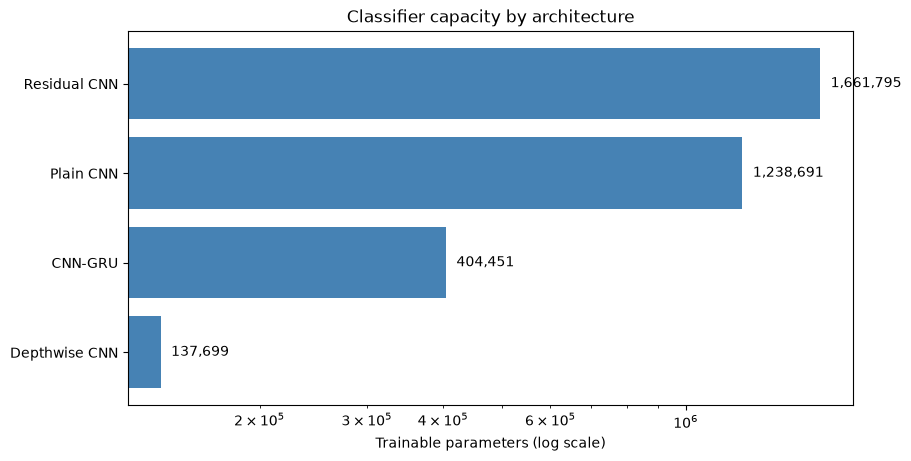

In [5]:
architecture_labels = {
    'residual_cnn': 'Residual CNN',
    'plain_cnn': 'Plain CNN',
    'depthwise_cnn': 'Depthwise CNN',
    'crnn': 'CNN-GRU',
}
parameter_rows = []
for architecture in ARCHITECTURES_TO_COMPARE:
    candidate = build_classifier(architecture, len(classes), DROPOUT, WIDTH)
    parameter_rows.append({
        'architecture': architecture,
        'label': architecture_labels[architecture],
        'trainable_parameters': count_trainable_parameters(candidate),
    })
parameter_table = pd.DataFrame(parameter_rows).sort_values('trainable_parameters')
display(parameter_table[['label', 'trainable_parameters']].style.format({'trainable_parameters': '{:,}'}))

fig, axis = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
bars = axis.barh(parameter_table['label'], parameter_table['trainable_parameters'], color='steelblue')
axis.set_xscale('log')
axis.set_xlabel('Trainable parameters (log scale)')
axis.set_title('Classifier capacity by architecture')
for bar, value in zip(bars, parameter_table['trainable_parameters']):
    axis.text(value * 1.04, bar.get_y() + bar.get_height() / 2, f'{value:,}', va='center')
plt.show()

### Inspect the Selected Architecture

Change `SELECTED_ARCHITECTURE` in the configuration cell to inspect another model. This cell performs only a small forward-shape check when you execute it; it does not train.

In [6]:
selected_model = build_classifier(
    SELECTED_ARCHITECTURE, num_classes=len(classes), dropout=DROPOUT, width=WIDTH
).to(device)
with torch.inference_mode():
    example_logits = selected_model(preview_specs[:2].to(device))
print(selected_model)
print(f"Architecture: {SELECTED_ARCHITECTURE}")
print(f"Trainable parameters: {count_trainable_parameters(selected_model):,}")
print("Logit shape:", tuple(example_logits.shape))
del selected_model


BirdSongCRNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU(inplace=True)
  )
  (features): Sequential(
    (0): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): SiLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1

## Controlled Training Protocol

All architecture runs use the same manifests, augmentation, width, dropout, AdamW optimizer, learning rate, weight decay, label smoothing, cosine schedule, gradient clipping, maximum epochs, and early-stopping rule. Repeating seeds measures sensitivity to initialization and stochastic training. The held-out test manifest is excluded from architecture selection.

In [7]:
def run_project_script(script_name, arguments):
    environment = os.environ.copy()
    existing_pythonpath = environment.get("PYTHONPATH")
    environment["PYTHONPATH"] = str(SOURCE_ROOT) + (
        os.pathsep + existing_pythonpath if existing_pythonpath else ""
    )
    command = [sys.executable, str(PROJECT_ROOT / "scripts" / script_name), *map(str, arguments)]
    print("Running:", " ".join(command))
    return subprocess.run(command, cwd=PROJECT_ROOT, env=environment, check=True)

common_training_arguments = [
    "--spectrogram-cache", CACHE_ROOT,
    "--spectrogram-config", CONFIG_PATH,
    "--train-manifest", TRAIN_MANIFEST,
    "--val-manifest", VALIDATION_MANIFEST,
    "--epochs", EPOCHS,
    "--patience", PATIENCE,
    "--batch-size", BATCH_SIZE,
    "--workers", TRAINING_WORKERS,
    "--learning-rate", LEARNING_RATE,
    "--weight-decay", WEIGHT_DECAY,
    "--label-smoothing", LABEL_SMOOTHING,
    "--width", WIDTH,
    "--dropout", DROPOUT,
    "--device", device,
]


### Optional: Train One Architecture

Set `RUN_SINGLE_MODEL = True` to train only `SELECTED_ARCHITECTURE`. Existing outputs are protected unless `OVERWRITE_RUNS = True`.

In [8]:
single_run_dir = LOCAL_SINGLE_RUN_ROOT / SELECTED_ARCHITECTURE / f"seed_{SEED}"
if RUN_SINGLE_MODEL:
    arguments = [
        "--architecture", SELECTED_ARCHITECTURE,
        "--seed", SEED,
        "--output-dir", single_run_dir,
        *common_training_arguments,
    ]
    if OVERWRITE_RUNS:
        arguments.append("--overwrite")
    run_project_script("03_train_classifier.py", arguments)
else:
    print("Skipped single-model training. Set RUN_SINGLE_MODEL = True to enable it.")


Skipped single-model training. Set RUN_SINGLE_MODEL = True to enable it.


### Optional: Run the Full Architecture Comparison

Set `RUN_ARCHITECTURE_COMPARISON = True` to train every selected architecture for every seed. With the defaults, this launches 12 independent runs and writes a reproducible protocol plus CSV and Markdown summaries.

In [9]:
if RUN_ARCHITECTURE_COMPARISON:
    arguments = [
        "--architectures", *ARCHITECTURES_TO_COMPARE,
        "--seeds", *COMPARISON_SEEDS,
        "--output-dir", LOCAL_COMPARISON_ROOT,
        *common_training_arguments,
    ]
    if OVERWRITE_RUNS:
        arguments.append("--overwrite")
    run_project_script("03_compare_classifier_architectures.py", arguments)
else:
    print("Skipped architecture comparison. Set RUN_ARCHITECTURE_COMPARISON = True to enable it.")


Skipped architecture comparison. Set RUN_ARCHITECTURE_COMPARISON = True to enable it.


## Validation Results

The default view is the tracked architecture comparison package. Set
USE_LOCAL_COMPARISON_RESULTS to True only when inspecting a fresh local rerun.


In [10]:
summary_path = ACTIVE_COMPARISON_ROOT / "summary.csv"
runs_path = ACTIVE_COMPARISON_ROOT / "runs.csv"

if summary_path.is_file() and runs_path.is_file():
    architecture_summary = pd.read_csv(summary_path)
    architecture_runs = pd.read_csv(runs_path)
    display_columns = [
        "architecture", "runs", "trainable_parameters",
        "validation_accuracy_mean", "validation_accuracy_std",
        "validation_macro_f1_mean", "validation_macro_f1_std",
        "best_epoch_mean",
    ]
    display(architecture_summary[display_columns].style.format({
        "trainable_parameters": "{:,.0f}",
        "validation_accuracy_mean": "{:.2%}",
        "validation_accuracy_std": "{:.2%}",
        "validation_macro_f1_mean": "{:.2%}",
        "validation_macro_f1_std": "{:.2%}",
        "best_epoch_mean": "{:.1f}",
    }))
    print("Evidence source:", ACTIVE_COMPARISON_ROOT)
else:
    architecture_summary = None
    architecture_runs = None
    print("No completed comparison found at:", ACTIVE_COMPARISON_ROOT)
    print("Enable RUN_ARCHITECTURE_COMPARISON, or provide the tracked comparison package.")


,architecture,runs,trainable_parameters,validation_accuracy_mean,validation_accuracy_std,validation_macro_f1_mean,validation_macro_f1_std,best_epoch_mean
0,crnn,3,"404,451",90.56%,1.39%,90.45%,1.45%,16.7
1,plain_cnn,3,"1,238,691",90.43%,1.74%,90.33%,1.76%,14.0
2,residual_cnn,3,"1,661,795",87.54%,0.99%,87.44%,0.97%,9.3
3,depthwise_cnn,3,"137,699",81.63%,2.70%,81.67%,2.94%,28.7


Evidence source: C:\Users\Harvey\Documents\Coding\bird_song_gen\artifacts\models\classifier\architecture_comparison


### Accuracy, Macro F1, and Parameter Efficiency

The first chart compares predictive performance. The second shows whether additional parameters translate into better validation accuracy.

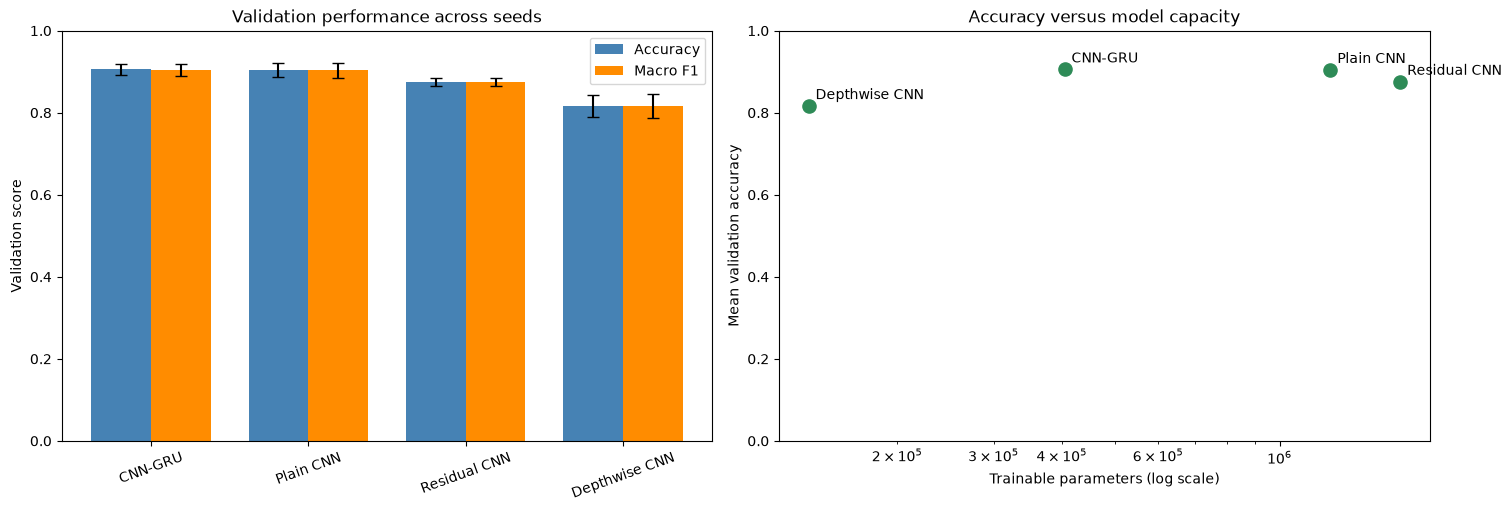

In [11]:
if architecture_summary is not None:
    results = architecture_summary.sort_values('validation_accuracy_mean', ascending=False).copy()
    labels_for_plot = results['architecture'].map(architecture_labels)
    positions = np.arange(len(results))
    bar_width = 0.38
    accuracy_sd = results['validation_accuracy_std'].fillna(0)
    macro_f1_sd = results['validation_macro_f1_std'].fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
    axes[0].bar(
        positions - bar_width / 2, results['validation_accuracy_mean'], bar_width,
        yerr=accuracy_sd, capsize=4, label='Accuracy', color='steelblue',
    )
    axes[0].bar(
        positions + bar_width / 2, results['validation_macro_f1_mean'], bar_width,
        yerr=macro_f1_sd, capsize=4, label='Macro F1', color='darkorange',
    )
    axes[0].set(
        xticks=positions, xticklabels=labels_for_plot, ylim=(0, 1),
        ylabel='Validation score', title='Validation performance across seeds',
    )
    axes[0].tick_params(axis='x', rotation=20)
    axes[0].legend()

    axes[1].scatter(
        results['trainable_parameters'], results['validation_accuracy_mean'],
        s=90, color='seagreen',
    )
    for row in results.itertuples(index=False):
        axes[1].annotate(
            architecture_labels[row.architecture],
            (row.trainable_parameters, row.validation_accuracy_mean),
            xytext=(5, 5), textcoords='offset points',
        )
    axes[1].set_xscale('log')
    axes[1].set(
        xlabel='Trainable parameters (log scale)', ylabel='Mean validation accuracy',
        title='Accuracy versus model capacity', ylim=(0, 1),
    )
    plt.show()
else:
    print('Run the comparison before plotting aggregate results.')

### Learning Curves by Architecture

Each line is one seed. This reveals unstable training, early plateaus, or overfitting that a single best-epoch number can hide.

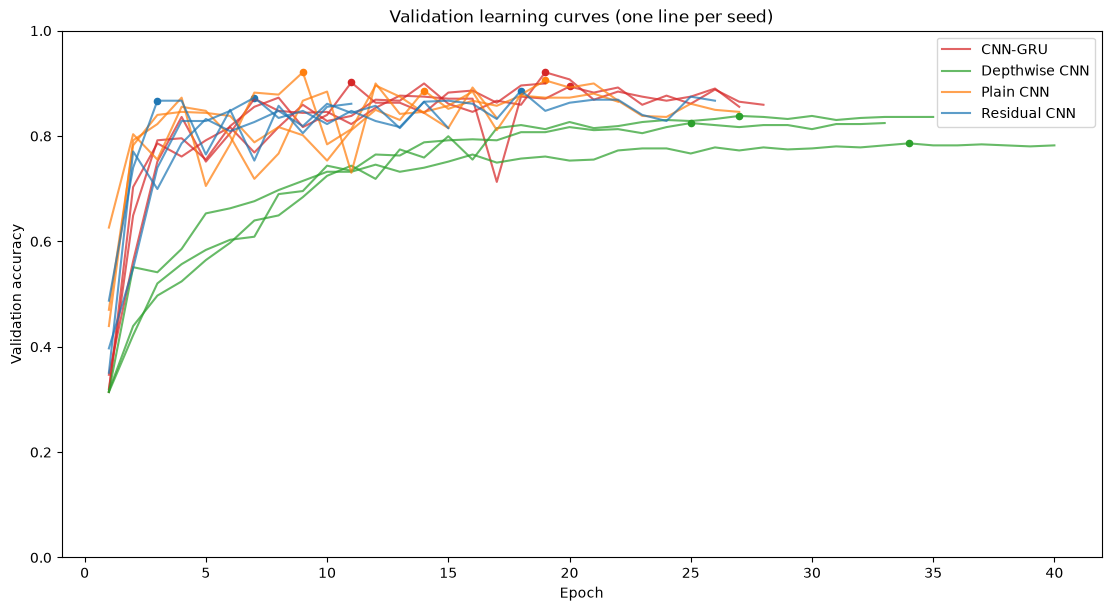

In [12]:
history_files = sorted(ACTIVE_COMPARISON_ROOT.glob("*/seed_*/history.csv"))
if history_files:
    fig, axis = plt.subplots(figsize=(11, 6), constrained_layout=True)
    colors = dict(zip(ARCHITECTURES_TO_COMPARE, plt.cm.tab10.colors))
    labeled_architectures = set()
    for history_path in history_files:
        architecture = history_path.parents[1].name
        seed_name = history_path.parent.name
        run_history = pd.read_csv(history_path)
        label = architecture_labels[architecture] if architecture not in labeled_architectures else None
        axis.plot(
            run_history["epoch"], run_history["val_accuracy"],
            color=colors[architecture], alpha=0.72, label=label,
        )
        labeled_architectures.add(architecture)
        best_row = run_history.loc[run_history["val_accuracy"].idxmax()]
        axis.scatter(best_row["epoch"], best_row["val_accuracy"], color=colors[architecture], s=20)
    axis.set(
        xlabel="Epoch", ylabel="Validation accuracy", ylim=(0, 1),
        title="Validation learning curves (one line per seed)",
    )
    axis.legend()
    plt.show()
else:
    print("No architecture histories found at:", ACTIVE_COMPARISON_ROOT)


## Architecture Selection

Choose the architecture with validation evidence, considering mean accuracy, macro F1, variability, parameter count, and learning behavior. The code below suggests the highest mean-validation-accuracy architecture and its strongest seed checkpoint; it does not change `FINAL_CHECKPOINT` automatically. Review the evidence and set that path manually in the configuration cell before touching the test set.

In [13]:
if architecture_summary is not None:
    suggested_architecture = architecture_summary.sort_values(
        "validation_accuracy_mean", ascending=False
    ).iloc[0]["architecture"]
    suggested_run = (
        architecture_runs[architecture_runs["architecture"] == suggested_architecture]
        .sort_values("validation_accuracy", ascending=False)
        .iloc[0]
    )
    suggested_seed = int(suggested_run["seed"])
    suggested_checkpoint = ACTIVE_COMPARISON_ROOT / suggested_architecture / f"seed_{suggested_seed}" / "best.pt"
    print("Suggested architecture from validation:", suggested_architecture)
    print("Strongest validation checkpoint for final evaluation:", suggested_checkpoint)
    print("The path is constructed from the active evidence package; historical run_dir strings are provenance only.")
else:
    print("Architecture selection is unavailable until the comparison is complete.")


Suggested architecture from validation: crnn
Strongest validation checkpoint for final evaluation: C:\Users\Harvey\Documents\Coding\bird_song_gen\artifacts\models\classifier\architecture_comparison\crnn\seed_777\best.pt
The path is constructed from the active evidence package; historical run_dir strings are provenance only.


## Held-out Test Evaluation

This section is deliberately gated. Set `FINAL_CHECKPOINT` to the validation-selected checkpoint and then set `RUN_TEST_EVALUATION = True`. Do not repeatedly evaluate alternatives on the test set, because that turns the test split into another validation set.

In [14]:
live_test_report = None
recorded_test_report = None
if RUN_TEST_EVALUATION:
    checkpoint_model, checkpoint_classes, checkpoint_config, checkpoint = load_checkpoint(
        FINAL_CHECKPOINT, device
    )
    assert checkpoint_classes == classes
    assert checkpoint_config == spectrogram_config

    predictions, targets, confidences = [], [], []
    checkpoint_model.eval()
    with torch.inference_mode():
        for batch_specs, batch_labels, _ in test_loader:
            probabilities = checkpoint_model(batch_specs.to(device)).softmax(1).cpu()
            predictions.extend(probabilities.argmax(1).tolist())
            targets.extend(batch_labels.tolist())
            confidences.extend(probabilities.max(1).values.tolist())

    live_test_report = classification_report(
        targets, predictions, target_names=classes, output_dict=True, zero_division=0
    )
    print("Architecture:", checkpoint.get("architecture", "crnn"))
    print("Checkpoint epoch:", checkpoint.get("epoch", "not recorded"))
    print(f"Test accuracy: {live_test_report['accuracy']:.2%}")
    print(f"Test macro F1: {live_test_report['macro avg']['f1-score']:.2%}")
    display(pd.DataFrame(live_test_report).T.loc[list(classes) + ["macro avg", "weighted avg"]])
else:
    if SELECTED_METRICS_PATH.is_file():
        metrics_payload = json.loads(SELECTED_METRICS_PATH.read_text(encoding="utf-8"))
        recorded_test_report = metrics_payload["report"]
        print("Showing the packaged held-out evaluation; live test inference is disabled.")
        print(f"Test accuracy: {recorded_test_report['accuracy']:.2%}")
        print(f"Test macro F1: {recorded_test_report['macro avg']['f1-score']:.2%}")
        display(pd.DataFrame(recorded_test_report).T.loc[list(classes) + ["macro avg", "weighted avg"]])
    else:
        print("No packaged metrics found at:", SELECTED_METRICS_PATH)

test_report = live_test_report if live_test_report is not None else recorded_test_report


Showing the packaged held-out evaluation; live test inference is disabled.
Test accuracy: 89.98%
Test macro F1: 90.16%


,precision,recall,f1-score,support
American Robin,0.920000,0.951724,0.935593,145.0
Northern Cardinal,0.920530,0.858025,0.888179,162.0
Song Sparrow,0.867021,0.895604,0.881081,182.0
macro avg,0.902517,0.901784,0.901618,489.0
weighted avg,0.900457,0.899796,0.899597,489.0


### Confusion Matrix

Rows show true species and columns show predictions. Inspect off-diagonal cells for systematic species confusions.

,American Robin,Northern Cardinal,Song Sparrow
American Robin,138,2,5
Northern Cardinal,3,139,20
Song Sparrow,9,10,163


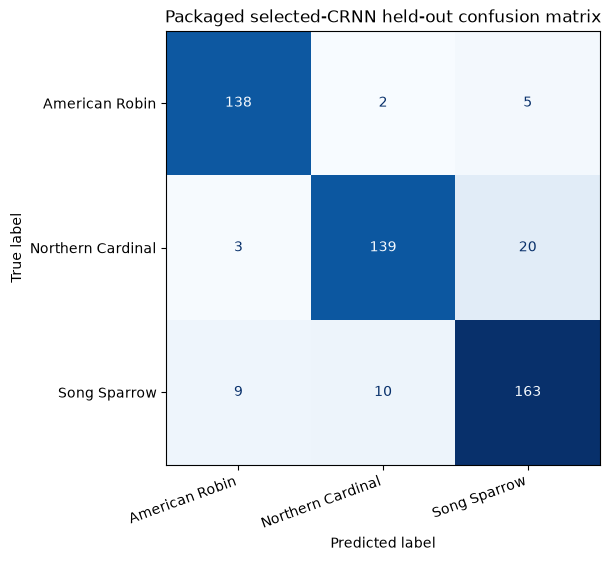

In [15]:
if RUN_TEST_EVALUATION and live_test_report is not None:
    matrix = confusion_matrix(targets, predictions, labels=range(len(classes)))
    matrix_title = "Live held-out test confusion matrix"
    mean_confidence = np.mean(confidences)
elif SELECTED_CONFUSION_PATH.is_file():
    confusion_table = pd.read_csv(SELECTED_CONFUSION_PATH, index_col=0)
    matrix = confusion_table.to_numpy(dtype=int)
    matrix_title = "Packaged selected-CRNN held-out confusion matrix"
    mean_confidence = None
else:
    matrix = None
    mean_confidence = None

if matrix is not None:
    display(pd.DataFrame(matrix, index=classes, columns=classes))
    display_matrix = ConfusionMatrixDisplay(matrix, display_labels=classes)
    fig, axis = plt.subplots(figsize=(7, 5.5), constrained_layout=True)
    display_matrix.plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
    axis.set_title(matrix_title)
    plt.xticks(rotation=20, ha="right")
    plt.show()
    if mean_confidence is not None:
        print(f"Mean prediction confidence: {mean_confidence:.2%}")
else:
    print("No confusion matrix is available.")


## Takeaways

The recorded CRNN comparison is the practical selection evidence: it reached
90.56% plus or minus 1.39% validation accuracy and 90.45% plus or minus 1.45%
validation macro F1 across three seeds with 404,451 trainable parameters.
Plain CNN was a near tie on validation quality but used 1,238,691 parameters.

The selected CRNN seed-777 checkpoint reached 92.10% validation accuracy and
92.06% validation macro F1 at epoch 19, then achieved 89.98% accuracy and
90.16% macro F1 on the one-time 489-clip held-out evaluation. The historical
v1 validation split contains nine exact train duplicates; none reaches test.
New reruns in this notebook use content-safe v2 manifests.

Classifier agreement is useful for species classification and generated-input
compatibility, but it is not a realism or audio-quality score.
